In [1]:
import pandas as pd 
import numpy as np

In [2]:
df = pd.read_csv("Zomato_Sales.csv")
print(df.head())

   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM 

In [3]:
print(df.tail())

      Restaurant ID           Restaurant Name  Country Code       City  \
9546        5915730               Naml۱ Gurme           208  ��stanbul   
9547        5908749              Ceviz A��ac۱           208  ��stanbul   
9548        5915807                     Huqqa           208  ��stanbul   
9549        5916112               A���k Kahve           208  ��stanbul   
9550        5927402  Walter's Coffee Roastery           208  ��stanbul   

                                                Address     Locality  \
9546  Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...     Karak�_y   
9547  Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...    Ko��uyolu   
9548  Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...  Kuru�_e��me   
9549  Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...  Kuru�_e��me   
9550  Cafea��a Mahallesi, Bademalt۱ Sokak, No 21/B, ...         Moda   

            Locality Verbose  Longitude   Latitude  \
9546     Karak�_y, ��stanbul  28.977392  41.022793   
9547    Ko��uy

In [4]:
print(df.shape)

(9551, 21)


In [5]:
df.columns.tolist()

['Restaurant ID',
 'Restaurant Name',
 'Country Code',
 'City',
 'Address',
 'Locality',
 'Locality Verbose',
 'Longitude',
 'Latitude',
 'Cuisines',
 'Average Cost for two',
 'Currency',
 'Has Table booking',
 'Has Online delivery',
 'Is delivering now',
 'Switch to order menu',
 'Price range',
 'Aggregate rating',
 'Rating color',
 'Rating text',
 'Votes']

In [6]:
df.info()
print("\nMissing:\n",df.isnull().sum())
print("\nTarget:\n",df["Has Online delivery"].value_counts(dropna=False))
print("\nDuplicates:",df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

In [7]:
missing = df.isnull().sum()
print(missing[missing > 0])

Cuisines    9
dtype: int64


In [8]:
df["Cuisines"] = df["Cuisines"].fillna(df["Cuisines"].mode()[0])

In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
df["Has Online delivery"].value_counts()

Has Online delivery
No     7100
Yes    2451
Name: count, dtype: int64

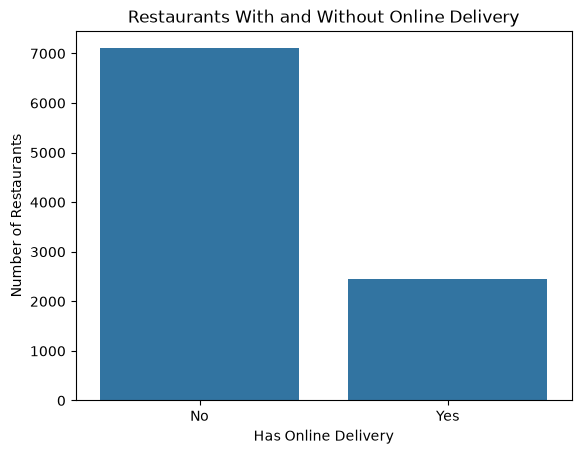

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="Has Online delivery")

plt.title("Restaurants With and Without Online Delivery")
plt.xlabel("Has Online Delivery")
plt.ylabel("Number of Restaurants")
plt.show()

In [12]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [13]:
numeric_cols = [
    "Average Cost for two",
    "Price range",
    "Aggregate rating",
    "Votes"
]

print(df[numeric_cols].describe())

       Average Cost for two  Price range  Aggregate rating         Votes
count           9551.000000  9551.000000       9551.000000   9551.000000
mean            1199.210763     1.804837          2.666370    156.909748
std            16121.183073     0.905609          1.516378    430.169145
min                0.000000     1.000000          0.000000      0.000000
25%              250.000000     1.000000          2.500000      5.000000
50%              400.000000     2.000000          3.200000     31.000000
75%              700.000000     2.000000          3.700000    131.000000
max           800000.000000     4.000000          4.900000  10934.000000


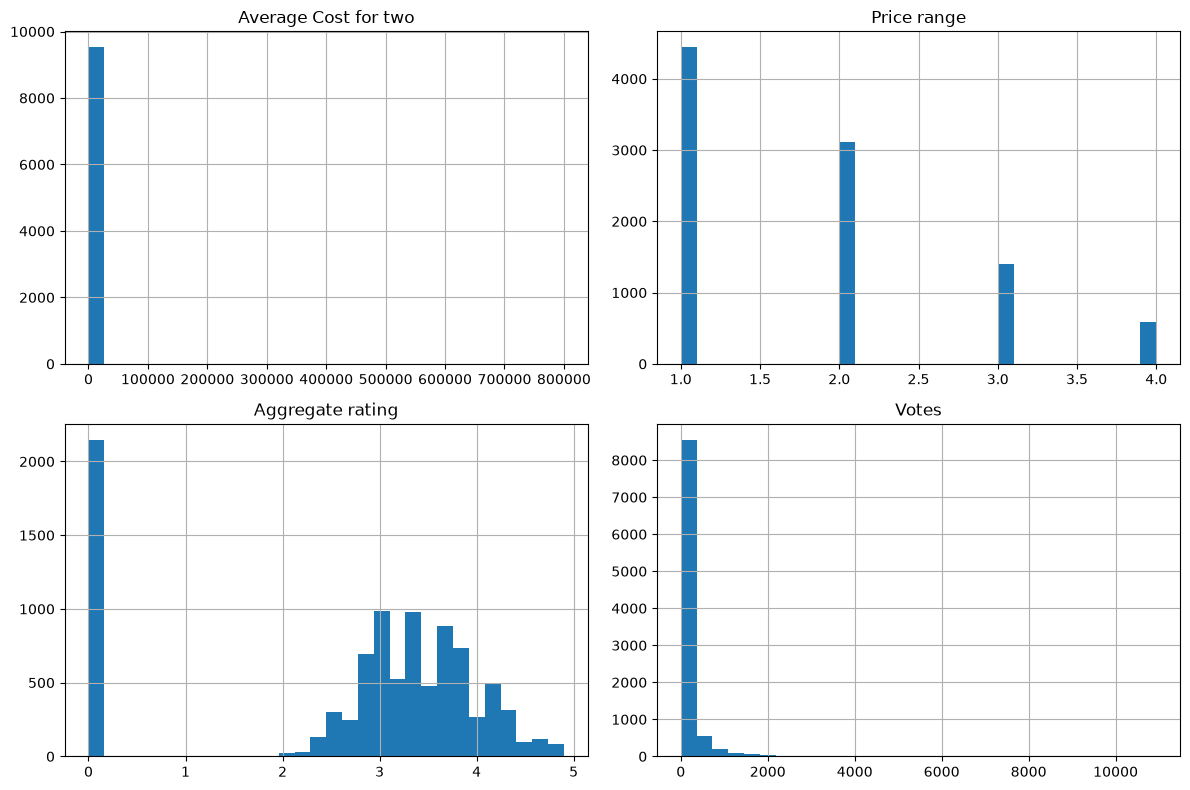

In [14]:
df[numeric_cols].hist(figsize=(12, 8), bins=30)

plt.tight_layout()
plt.show()

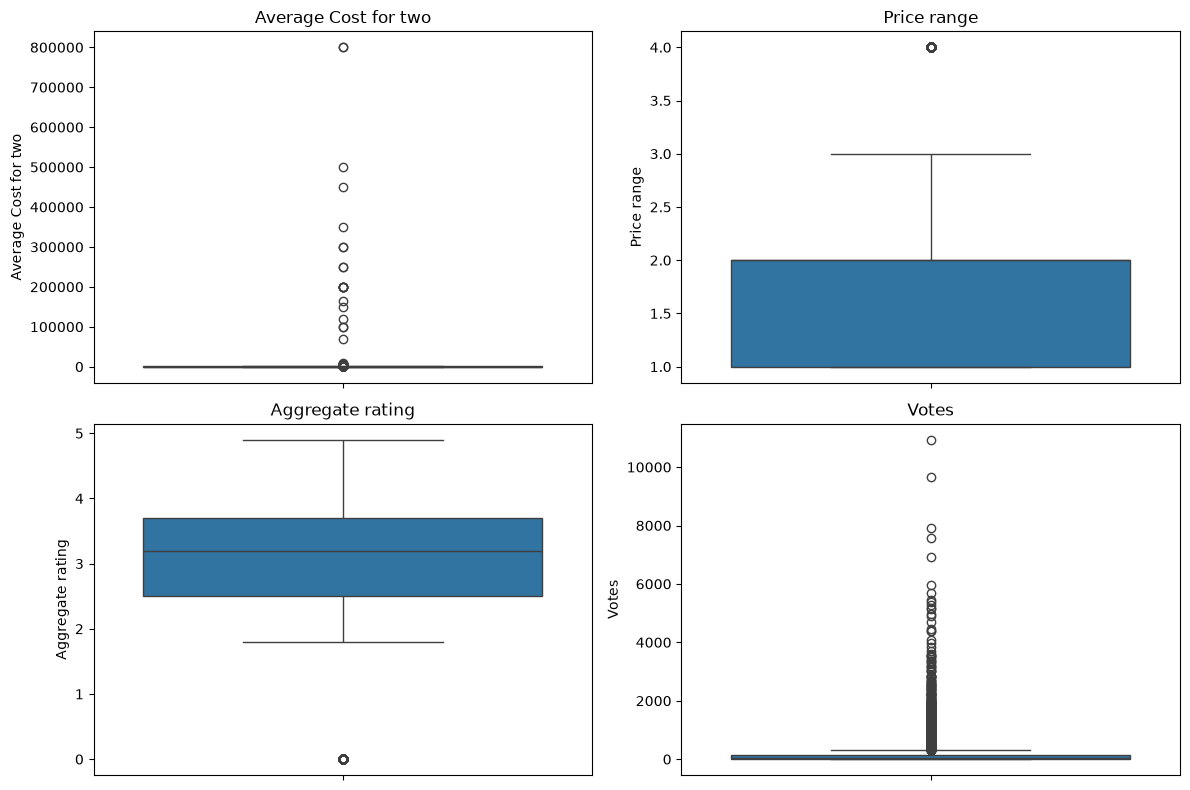

In [15]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

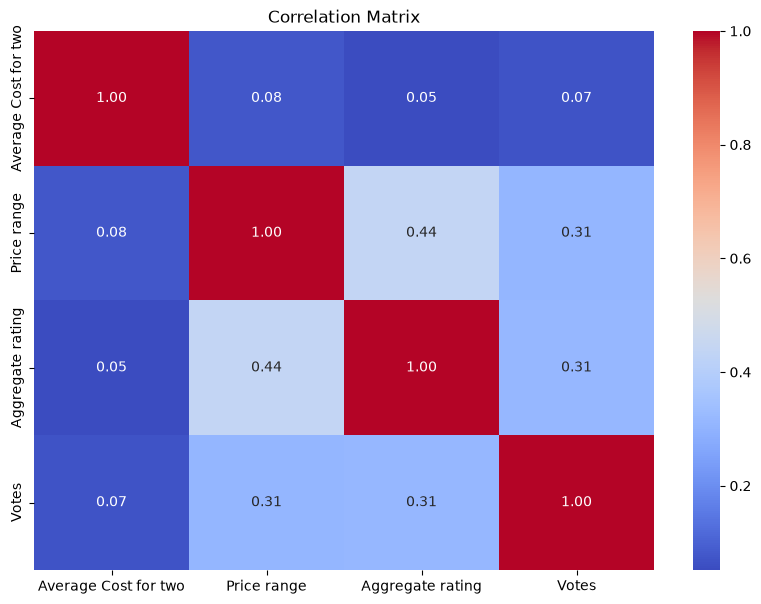

In [16]:
plt.figure(figsize=(10, 7))

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [17]:
pd.crosstab(
    df["Price range"],
    df["Has Online delivery"],
    normalize="index"
).mul(100).round(2)

Has Online delivery,No,Yes
Price range,,
1,84.23,15.77
2,58.69,41.31
3,70.81,29.19
4,90.96,9.04


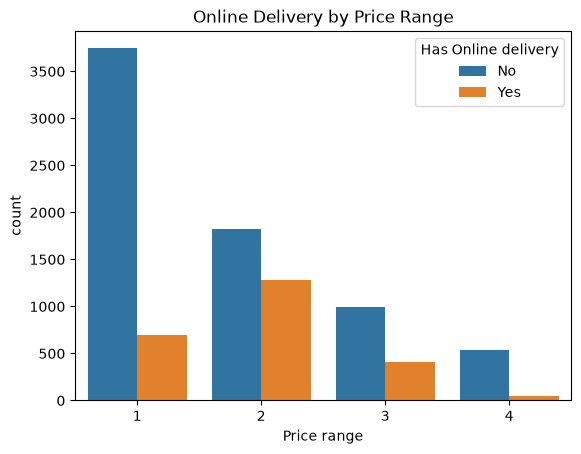

In [18]:
sns.countplot(
    data=df,
    x="Price range",
    hue="Has Online delivery"
)

plt.title("Online Delivery by Price Range")
plt.show()

In [19]:
pd.crosstab(
    df["Has Table booking"],
    df["Has Online delivery"],
    normalize="index"
).mul(100).round(2)

Has Online delivery,No,Yes
Has Table booking,,
No,75.98,24.02
Yes,62.44,37.56


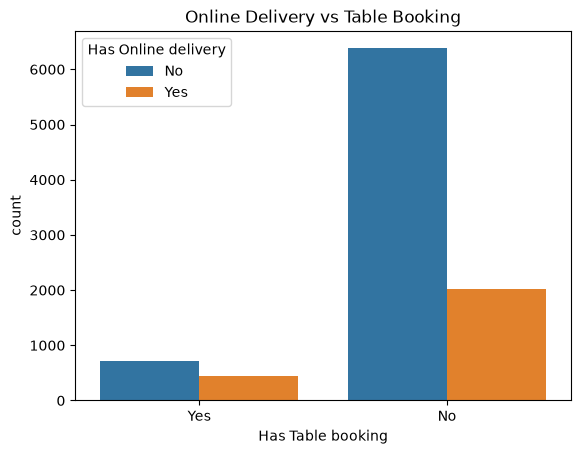

In [20]:
sns.countplot(
    data=df,
    x="Has Table booking",
    hue="Has Online delivery"
)

plt.title("Online Delivery vs Table Booking")
plt.show()

In [21]:
df.groupby("Has Online delivery")[
    ["Average Cost for two",
     "Price range",
     "Aggregate rating",
     "Votes"]
].mean()

,Average Cost for two,Price range,Aggregate rating,Votes
Has Online delivery,,,,
No,1378.919296,1.763380,2.465296,138.131127
Yes,678.635251,1.924929,3.248837,211.307222


In [22]:
print(df["City"].value_counts().head(10))

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Amritsar          21
Bhubaneshwar      21
Guwahati          21
Lucknow           21
Name: count, dtype: int64


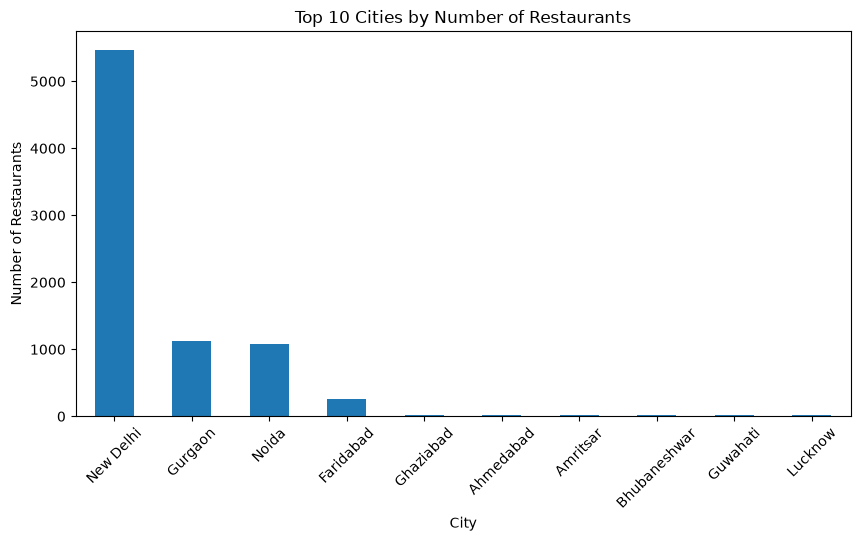

In [23]:
top_cities = df["City"].value_counts().head(10)

top_cities.plot(kind="bar", figsize=(10, 5))

plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.show()

In [24]:
df["Switch to order menu"].value_counts()

Switch to order menu
No    9551
Name: count, dtype: int64

In [25]:
features = [
    "Country Code",
    "City",
    "Average Cost for two",
    "Currency",
    "Has Table booking",
    "Price range",
    "Aggregate rating",
    "Votes"
]

In [26]:
target = "Has Online delivery"

In [27]:
df["Has Online delivery"] = df["Has Online delivery"].map({
    "No": 0,
    "Yes": 1
})

In [28]:
X = df[features]
y = df["Has Online delivery"]

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

categorical_features = [
    "Country Code",
    "City",
    "Currency",
    "Has Table booking"
]

numerical_features = [
    "Average Cost for two",
    "Price range",
    "Aggregate rating",
    "Votes"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [32]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

In [33]:
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", model)
])

In [34]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Country Code','City','Average Cost for two',...,'Price range', 'Aggregate rating','Votes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

In [35]:
y_pred = pipeline.predict(X_test)

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.6242804814233386
Precision: 0.3914285714285714
Recall   : 0.8387755102040816
F1 Score : 0.5337662337662338

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.55      0.69      1421
           1       0.39      0.84      0.53       490

    accuracy                           0.62      1911
   macro avg       0.65      0.69      0.61      1911
weighted avg       0.78      0.62      0.65      1911



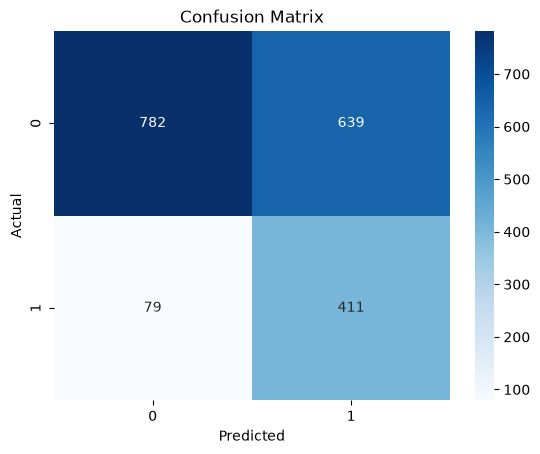

In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [38]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=8,
    class_weight="balanced",
    random_state=42
)

dt_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", dt_model)
])

dt_pipeline.fit(X_train, y_train)

dt_pred = dt_pipeline.predict(X_test)

print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))

Accuracy : 0.7095761381475667
Precision: 0.465016146393972
Recall   : 0.8816326530612245
F1 Score : 0.6088794926004228


In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", rf_model)
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Accuracy : 0.7336473050758765
Precision: 0.48924122310305773
Recall   : 0.8816326530612245
F1 Score : 0.629278951201748


In [40]:
sample = pd.DataFrame({
    "Country Code": [1],
    "City": ["New Delhi"],
    "Average Cost for two": [500],
    "Currency": ["Indian Rupees(Rs.)"],
    "Has Table booking": ["No"],
    "Price range": [2],
    "Aggregate rating": [3.8],
    "Votes": [250]
})

prediction = pipeline.predict(sample)

if prediction[0] == 1:
    print("Has Online Delivery: YES")
else:
    print("Has Online Delivery: NO")

Has Online Delivery: YES
